In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.signal_processing import DataProcessor
from src.visualizer import VesselVisualizer

In [4]:
# Path to your raw telemetry
raw_data_file = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"

# Instantiate
loader = VesselDataLoader(raw_data_file)

# Load and clean the data
clean_df = loader.load_and_clean()

Successfully loaded, cleaned, and processed 2880 telemetry rows.


Filter bypassed: Using raw signals.


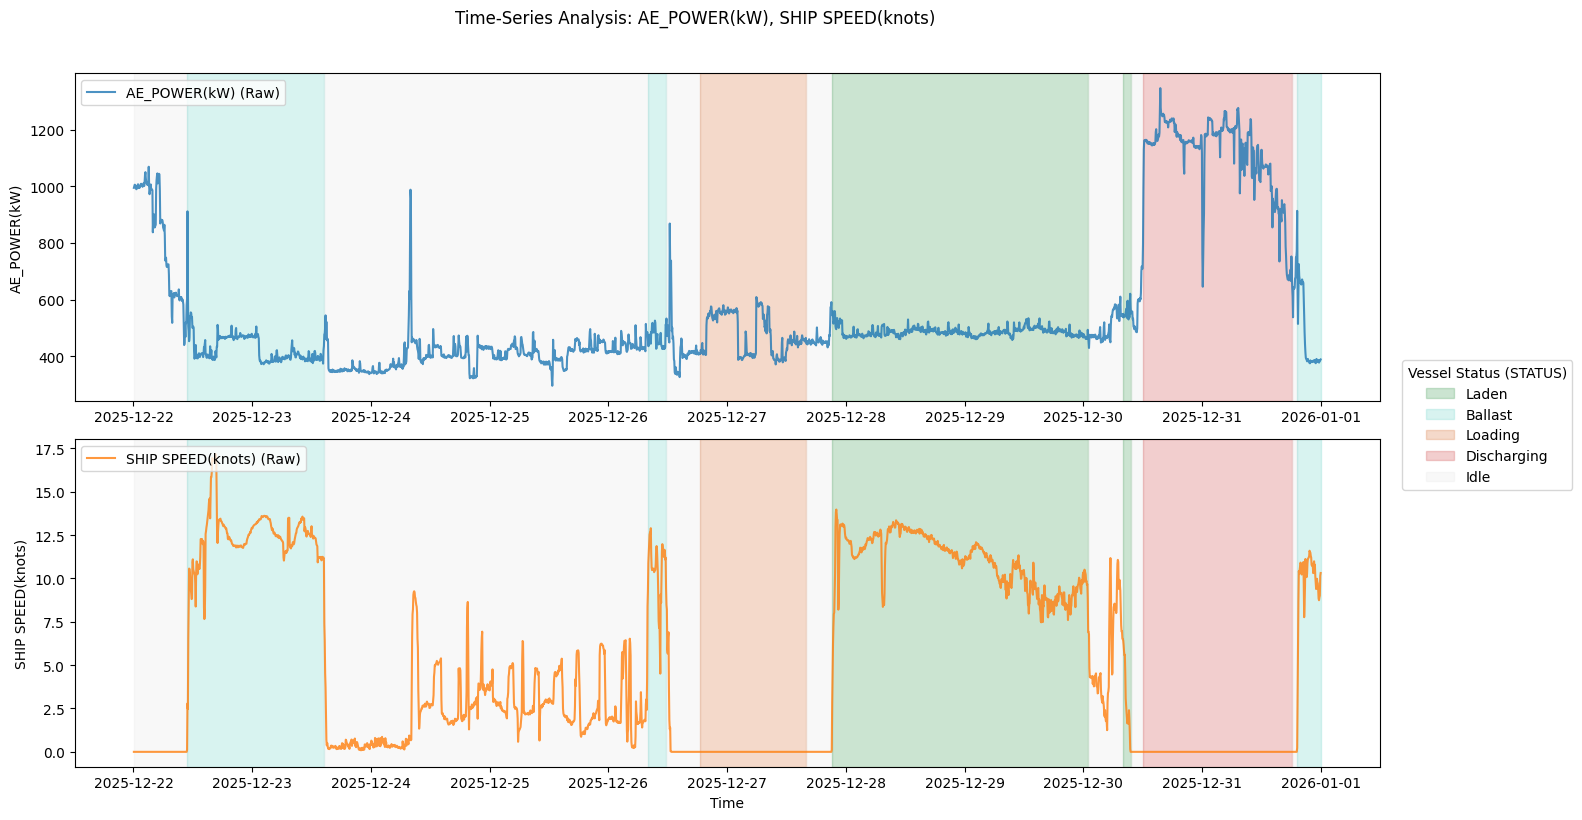

In [5]:
raw_df = DataProcessor(clean_df).extract_features_and_filter(filter_method='raw', window_size=10)
raw_plotter = VesselVisualizer(raw_df)
fig, ax = raw_plotter.plot_series(columns=['AE_POWER(kW)', 'SHIP SPEED(knots)'],subplots=True, status_col='STATUS')

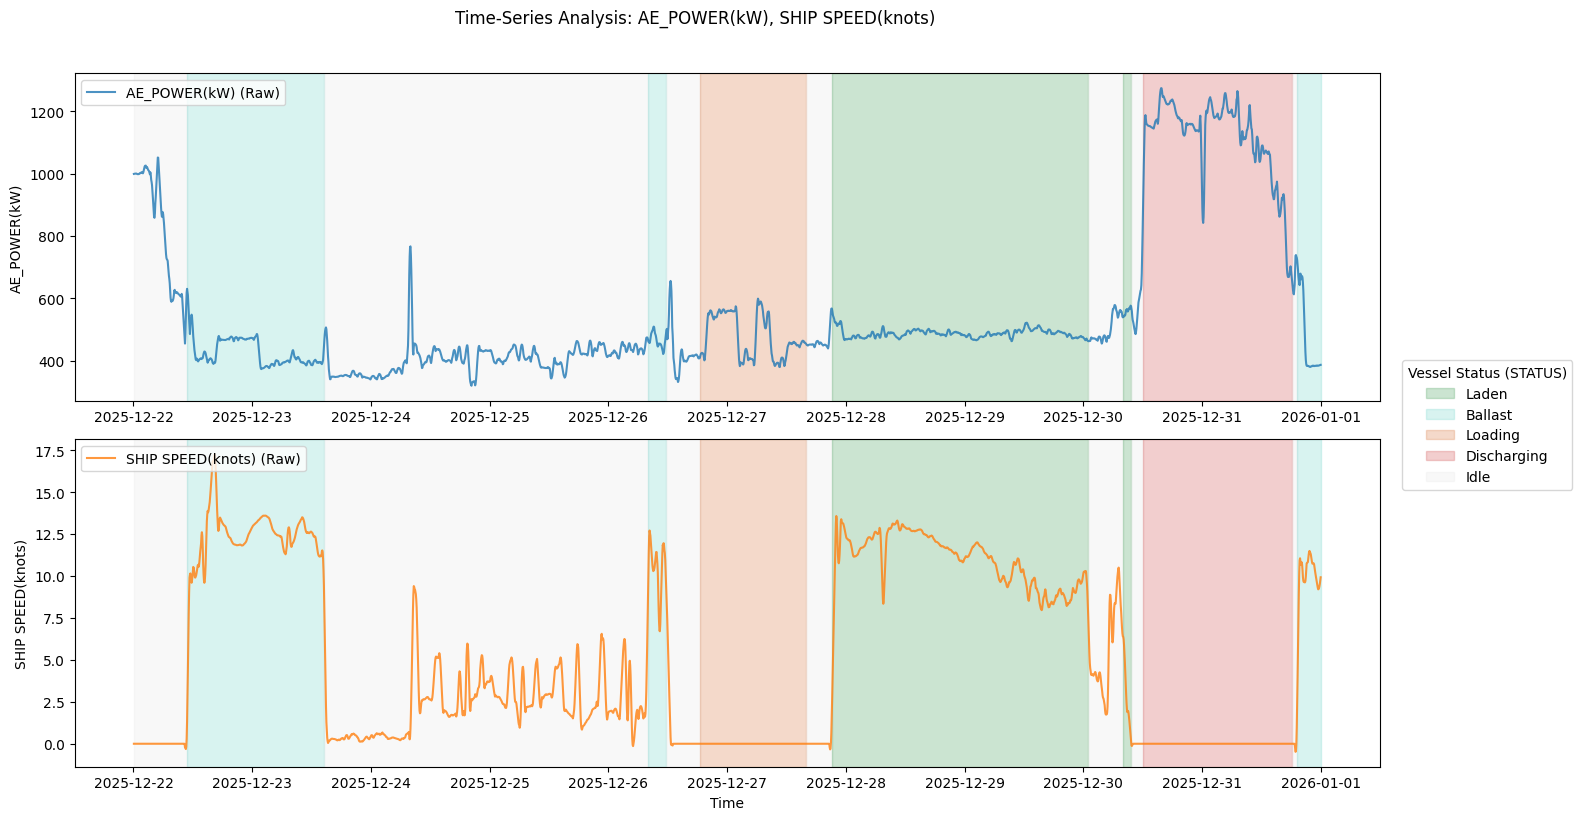

In [15]:
savgol_df = DataProcessor(clean_df).extract_features_and_filter(filter_method='savgol', window_size=12)
savgol_plotter = VesselVisualizer(savgol_df)
fig, ax = savgol_plotter.plot_series(columns=['AE_POWER(kW)', 'SHIP SPEED(knots)'],subplots=True, status_col='STATUS')

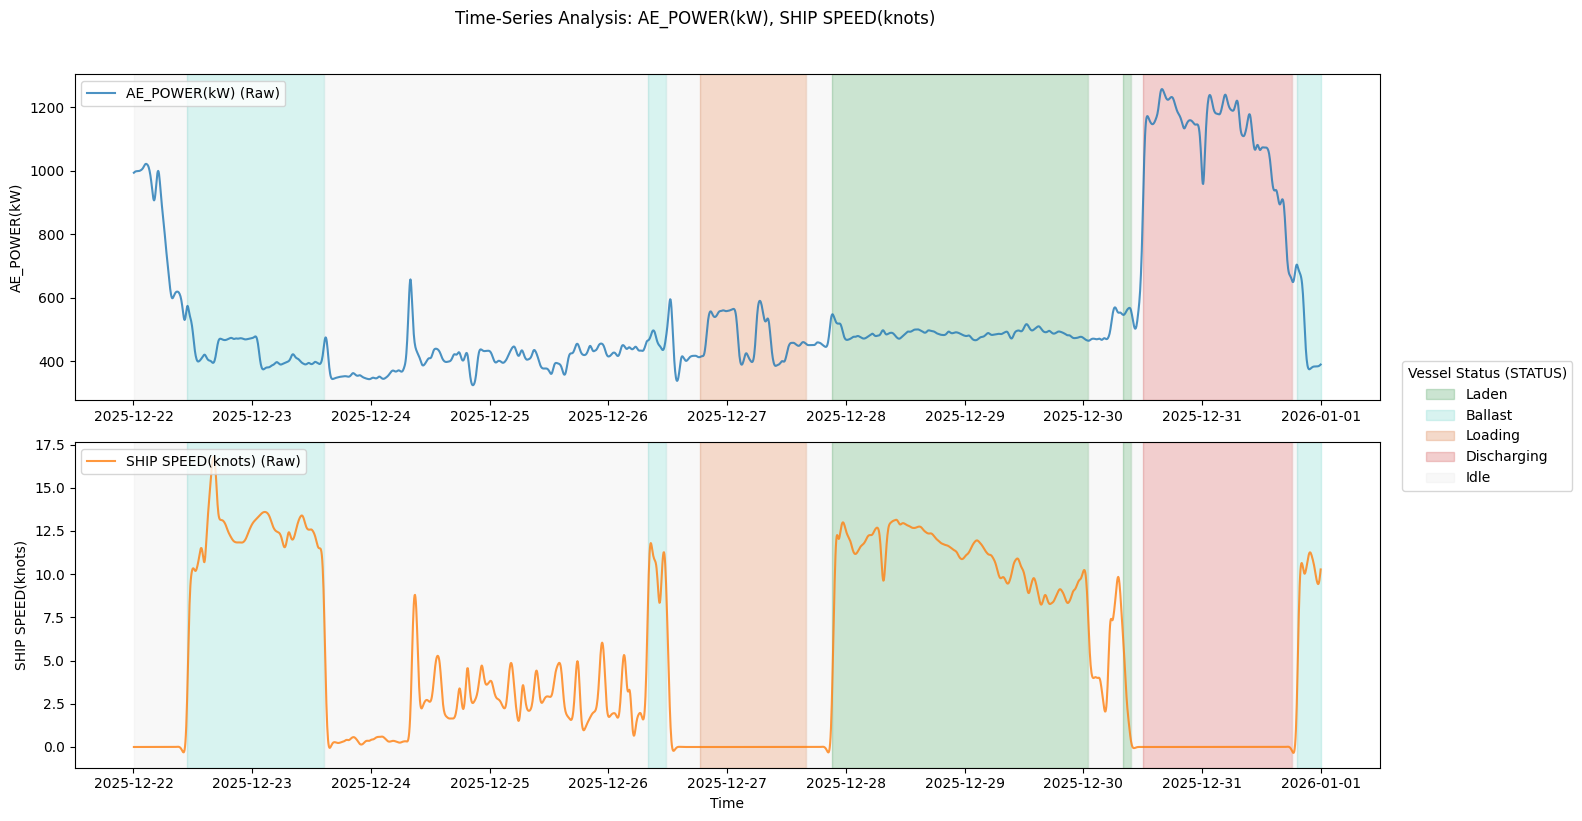

In [14]:
butter_df = DataProcessor(clean_df).extract_features_and_filter(filter_method='butterworth', cutoff=0.1, order=2)
butter_plotter = VesselVisualizer(butter_df)
fig, ax = butter_plotter.plot_series(columns=['AE_POWER(kW)', 'SHIP SPEED(knots)'],subplots=True, status_col='STATUS')